# 9. Classification
In this notebook, we explore how machine learning models can be used to classify samples based on their microbiome composition. The goal of this analysis is to evaluate whether microbial profiles contain enough discriminatory signal to accurately predict a selected metadata category, such as diet, delivery mode, or geographic origin. We begin by preparing the feature table and metadata, filtering samples, and selecting the appropriate taxonomic level. After this, we split the dataset into training and test sets to ensure that model performance is evaluated fairly.

Using the processed data, we then train a supervised classifier and assess how well it can distinguish between the selected groups. Feature importance scores help identify which microbial taxa contribute most to the prediction task, providing insight into biological interpretation in addition to model performance. To ensure the model is reliable, we also check for signs of overfitting or underfitting by comparing training and test accuracy and, when needed, examining learning curves.

<div style="border:2px solid red; padding:10px; background-color:#ffe6e6;">
<b>TODO:</b> Not correcting for Host ID  -> model might be leaking information across samples from the same child.
</div>


### Notebook Structure

**1.** Classification pipeline
**2.** Test for overfitting or underfitting

## Import data & packages

In [1]:
# 1 - Import packages
import pandas as pd
import numpy as np
import glob
import re
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap, BoundaryNorm
from matplotlib.patches import Patch
import seaborn as sns
import os
import qiime2 as q2
from qiime2 import Visualization
from biom import load_table
from ipywidgets import Dropdown, VBox

%matplotlib inline

In [2]:
# 2 - Set working directory
# The working directory should normally default to the 'scripts' folder. 
# If it doesn't, set it manually using the command below.
# os.chdir("/home/jovyan/MicrobiomeAnalysis_TummyTribe/scripts")  # Adjust this path to match your folder structure.

# Verify that your working directory is the 'scripts' folder inside the main project directory (.../MicrobiomeAnalysis_TummyTribe/scripts)
cwd = os.getcwd()
if not cwd.endswith("MicrobiomeAnalysis_TummyTribe/scripts"):
    print("WARNING: The working directory is not set to the 'scripts' folder inside 'MicrobiomeAnalysis_TummyTribe'!")
    print("Current working directory:", cwd)
    print("Please set it manually using os.chdir().")
else:
    print(f"Working directory is correctly set to the 'scripts' folder (\"{cwd}\").")

Working directory is correctly set to the 'scripts' folder ("/home/jovyan/MicrobiomeAnalysis_TummyTribe/scripts").


In [3]:
# 3 - Data directories
raw_data_dir = "../data/raw"
processed_data_dir = "../data/processed"
meta_data_dir = "../data/processed/metadata"
raw_data_dir = "../data/raw"
denoised_data_dir = "../data/processed/denoising"
taxonomy_data_dir = "../data/processed/taxonomy"
diversity_data_dir = "../data/processed/diversity"
phylogeny_data_dir = "../data/processed/phylogeny"
classification_dir = "../data/processed/classification"
# Create the new differential abundance analysis folder

In [4]:
%%bash -s "$classification_dir"
mkdir -p "$1"

### Set run and metric to work with

In [5]:
# 1. Select metadata column for classification
categorical_cols = ["geo_location_name", "delivery_mode", "sex", "diet_milk", "treatment_exposure"]

meta_selector = Dropdown(
    options=sorted(categorical_cols),
    value="diet_milk",
    description="Metadata:",
)

# 2. Select taxonomic level (all lowercase)
tax_levels = ["phylum", "class", "order", "family", "genus", "species"]

tax_selector = Dropdown(
    options=tax_levels,
    value="genus",
    description="Tax level:",
)

# 3. Select classifier
classifier_options = [
    'RandomForestClassifier',
    'ExtraTreesClassifier',
    'GradientBoostingClassifier',
    'AdaBoostClassifier[DecisionTree]',
    'AdaBoostClassifier[ExtraTrees]',
    'KNeighborsClassifier',
    'LinearSVC',
    'SVC'
]

classifier_selector = Dropdown(
    options=classifier_options,
    value='RandomForestClassifier',
    description="Classifier:",
)

VBox([
    meta_selector,
    tax_selector,
    classifier_selector,
])

In [26]:
# Read user selections
column_to_investigate = meta_selector.value
selected_level = tax_selector.value
classifier_choice = classifier_selector.value

## 1. Classification Pipeline

In this step, we prepare the output folder for this run and filter the feature table to the selected taxonomic level. QIIME uses prefixes such as g__ or f__ to indicate taxonomic rank, so we map the selected level to the right prefix. The filtered table becomes the starting point for all downstream classification steps.

In [27]:
# Map selected taxonomy level to the correct QIIME prefix
prefix_map = {
    "phylum": "p__",
    "class": "c__",
    "order": "o__",
    "family": "f__",
    "genus": "g__",
    "species": "s__"
}
prefix = prefix_map[selected_level]

# Clean classifier name so it can be used inside folder names
classifier_clean = classifier_choice.replace("[", "_").replace("]", "").replace(" ", "_")

# Build output folder path that encodes metadata column, level, and classifier
out_dir = f"{classification_dir}/results-{column_to_investigate}-{selected_level}-{classifier_clean}"

# Make sure the directory exists
! mkdir -p "{out_dir}"

# Filter the table to include only features at the selected taxonomy level
! qiime taxa filter-table \
  --i-table "{denoised_data_dir}/dada2_table.qza" \
  --i-taxonomy "{taxonomy_data_dir}/taxonomy.qza" \
  --p-include "{prefix}" \
  --p-exclude "{prefix};" \
  --o-filtered-table "{out_dir}/{selected_level}_only_table.qza"

/opt/conda/lib/python3.10/site-packages/unifrac/__init__.py:9: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources
Saved FeatureTable[Frequency] to: ../data/processed/classification/results-diet_milk-genus-ExtraTreesClassifier/genus_only_table.qza


After filtering the feature table to only the selected taxonomic level, we collapse the table so that all features belonging to the same taxon are summed. This creates a clean table where each row corresponds to a unique taxon at the chosen level.

In [28]:
# Map taxonomy rank to the correct QIIME collapse level
qiime_level_map = {
    "phylum": 2,
    "class": 3,
    "order": 4,
    "family": 5,
    "genus": 6,
    "species": 7
}
collapse_level = qiime_level_map[selected_level]

# File locations for collapse step
input_table = f"{out_dir}/{selected_level}_only_table.qza"
collapsed_out = f"{out_dir}/collapsed_table.qza"

print("Looking for input table:", input_table)

# Collapse all features that belong to the same taxon
! qiime taxa collapse \
  --i-table "{input_table}" \
  --i-taxonomy "{taxonomy_data_dir}/taxonomy.qza" \
  --p-level {collapse_level} \
  --o-collapsed-table "{collapsed_out}"

Looking for input table: ../data/processed/classification/results-diet_milk-genus-ExtraTreesClassifier/genus_only_table.qza
/opt/conda/lib/python3.10/site-packages/unifrac/__init__.py:9: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources
Saved FeatureTable[Frequency] to: ../data/processed/classification/results-diet_milk-genus-ExtraTreesClassifier/collapsed_table.qza


During classification, samples with missing metadata in the selected target column (for example, unknown diet type) can cause errors or introduce artificial classes. Instead of filling missing entries, we remove these samples to keep the classifier reliable.

Here we load the metadata file and remove any samples that do not have a value for the selected metadata column. We save this cleaned metadata into the output directory so all files related to this run stay together.

In [29]:
# Load full metadata table
m_raw = pd.read_csv(f"{meta_data_dir}/metadata_merged.tsv", sep="\t")

# IMPORTANT: set sample ID column as the index so QIIME recognizes it
m_raw = m_raw.set_index("id")

# Count samples before filtering
total_samples = len(m_raw)

# Drop samples missing the selected target variable
m = m_raw.dropna(subset=[column_to_investigate])

# Count remaining samples
remaining_samples = len(m)
removed_samples = total_samples - remaining_samples

# Save cleaned metadata into the run folder
clean_meta_path = f"{out_dir}/metadata_cleaned_{column_to_investigate}.tsv"
m.to_csv(clean_meta_path, sep="\t")   # DO NOT use index=False!

print("Saved cleaned metadata to:", clean_meta_path)
print(f"Total samples:     {total_samples}")
print(f"Remaining samples: {remaining_samples}")
print(f"Dropped samples:   {removed_samples}")

Saved cleaned metadata to: ../data/processed/classification/results-diet_milk-genus-ExtraTreesClassifier/metadata_cleaned_diet_milk.tsv
Total samples:     357
Remaining samples: 270
Dropped samples:   87


Now that we have cleaned metadata, we filter the collapsed feature table so it only contains samples still included in the analysis.

In [30]:
# Filter the collapsed table so that only samples in the cleaned metadata remain
! qiime feature-table filter-samples \
  --i-table "{out_dir}/collapsed_table.qza" \
  --m-metadata-file "{clean_meta_path}" \
  --o-filtered-table "{out_dir}/collapsed_table_filtered.qza"

/opt/conda/lib/python3.10/site-packages/unifrac/__init__.py:9: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources
Saved FeatureTable[Frequency] to: ../data/processed/classification/results-diet_milk-genus-ExtraTreesClassifier/collapsed_table_filtered.qza


QIIME’s classify-samples trains a supervised classifier using the filtered table. The classifier type, metadata column, and test size are all controlled by our earlier parameters. Results are saved in a classifier-specific output folder.

In [31]:
# Clean classifier name for folder safety
classifier_clean = classifier_choice.replace("[", "_").replace("]", "").replace(" ", "_")

# Folder where classifier results will be stored
qiime_clf_dir = f"{classification_dir}/qiime-classifier-{column_to_investigate}-{selected_level}-{classifier_clean}"

# Remove old folder if it exists
cmd = f"""
if [ -d "{qiime_clf_dir}" ]; then
    rm -r "{qiime_clf_dir}"
fi

qiime sample-classifier classify-samples \
  --i-table "{out_dir}/collapsed_table_filtered.qza" \
  --m-metadata-file "{clean_meta_path}" \
  --m-metadata-column "{column_to_investigate}" \
  --p-test-size 0.2 \
  --p-estimator "{classifier_choice}" \
  --p-random-state 15 \
  --p-n-jobs 3 \
  --output-dir "{qiime_clf_dir}"
"""

print(cmd)
!bash -c "{cmd}"


if [ -d "../data/processed/classification/qiime-classifier-diet_milk-genus-ExtraTreesClassifier" ]; then
    rm -r "../data/processed/classification/qiime-classifier-diet_milk-genus-ExtraTreesClassifier"
fi

qiime sample-classifier classify-samples   --i-table "../data/processed/classification/results-diet_milk-genus-ExtraTreesClassifier/collapsed_table_filtered.qza"   --m-metadata-file "../data/processed/classification/results-diet_milk-genus-ExtraTreesClassifier/metadata_cleaned_diet_milk.tsv"   --m-metadata-column "diet_milk"   --p-test-size 0.2   --p-estimator "ExtraTreesClassifier"   --p-random-state 15   --p-n-jobs 3   --output-dir "../data/processed/classification/qiime-classifier-diet_milk-genus-ExtraTreesClassifier"

/opt/conda/lib/python3.10/site-packages/unifrac/__init__.py:9: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from us

After classification, we load the accuracy visualization generated by QIIME. This allows us to inspect overall model performance.

In [32]:
viz_path = f"{qiime_clf_dir}/accuracy_results.qzv"
Visualization.load(viz_path)

<visualization: Visualization uuid: 697a6741-54a5-40e8-bc3b-e742c3638c47>

Here we tabulate the model predictions, predicted probabilities, and true class labels into a single visualization to make inspection easier.

In [33]:
cmd = f"""
qiime metadata tabulate \
  --m-input-file "{qiime_clf_dir}/test_targets.qza" \
  --m-input-file "{qiime_clf_dir}/predictions.qza" \
  --m-input-file "{qiime_clf_dir}/probabilities.qza" \
  --o-visualization "{qiime_clf_dir}/test_predprob.qzv"
"""

print(cmd)
!bash -c "{cmd}"


qiime metadata tabulate   --m-input-file "../data/processed/classification/qiime-classifier-diet_milk-genus-ExtraTreesClassifier/test_targets.qza"   --m-input-file "../data/processed/classification/qiime-classifier-diet_milk-genus-ExtraTreesClassifier/predictions.qza"   --m-input-file "../data/processed/classification/qiime-classifier-diet_milk-genus-ExtraTreesClassifier/probabilities.qza"   --o-visualization "../data/processed/classification/qiime-classifier-diet_milk-genus-ExtraTreesClassifier/test_predprob.qzv"

/opt/conda/lib/python3.10/site-packages/unifrac/__init__.py:9: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources
/opt/conda/lib/python3.10/site-packages/q2_sample_classifier/_transformer.py:76: FutureWarning: errors='ignore' is deprecated and will raise in a futu

Now we load the visualization that combines true labels, predictions, and probabilities.

In [34]:
viz_path = f"{qiime_clf_dir}/test_predprob.qzv"
Visualization.load(viz_path)

<visualization: Visualization uuid: 5d0a3fa3-d720-4387-8a94-7faa29ecd808>

QIIME also provides a feature importance vector. Here we convert it into a table for inspection.

In [35]:
cmd = f"""
qiime metadata tabulate \
  --m-input-file "{qiime_clf_dir}/feature_importance.qza" \
  --o-visualization "{qiime_clf_dir}/feature_importance.qzv"
"""

print(cmd)
!bash -c "{cmd}"


qiime metadata tabulate   --m-input-file "../data/processed/classification/qiime-classifier-diet_milk-genus-ExtraTreesClassifier/feature_importance.qza"   --o-visualization "../data/processed/classification/qiime-classifier-diet_milk-genus-ExtraTreesClassifier/feature_importance.qzv"

/opt/conda/lib/python3.10/site-packages/unifrac/__init__.py:9: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources
Saved Visualization to: ../data/processed/classification/qiime-classifier-diet_milk-genus-ExtraTreesClassifier/feature_importance.qzv


This step loads two key visualizations: the feature importance ranking and the heatmap showing how these important features vary across groups.

In [36]:
viz_files = [
    ("Feature importance", "feature_importance.qzv"),
    ("Heatmap", "heatmap.qzv"),
]

for label, fname in viz_files:
    viz_path = f"{qiime_clf_dir}/{fname}"
    print(f"Showing visualization: {label}")
    viz = Visualization.load(viz_path)
    display(viz)

Showing visualization: Feature importance


<visualization: Visualization uuid: 629a5d76-3001-4809-8b53-a7c20b6ccbe8>

Showing visualization: Heatmap


<visualization: Visualization uuid: d4061cc2-de7c-4a98-a98a-ae3960ac760d>

QIIME can generate a heatmap of the top features based on importance scores. Here we select the top 30 and visualize them.

In [37]:
cmd = f"""
qiime sample-classifier heatmap \
  --i-table "{out_dir}/collapsed_table_filtered.qza" \
  --i-importance "{qiime_clf_dir}/feature_importance.qza" \
  --m-sample-metadata-file "{clean_meta_path}" \
  --m-sample-metadata-column "{column_to_investigate}" \
  --p-group-samples \
  --p-feature-count 30 \
  --o-filtered-table "{qiime_clf_dir}/important-feature-table-top-30.qza" \
  --o-heatmap "{qiime_clf_dir}/important-feature-heatmap.qzv"
"""

print(cmd)
!bash -c "{cmd}"


qiime sample-classifier heatmap   --i-table "../data/processed/classification/results-diet_milk-genus-ExtraTreesClassifier/collapsed_table_filtered.qza"   --i-importance "../data/processed/classification/qiime-classifier-diet_milk-genus-ExtraTreesClassifier/feature_importance.qza"   --m-sample-metadata-file "../data/processed/classification/results-diet_milk-genus-ExtraTreesClassifier/metadata_cleaned_diet_milk.tsv"   --m-sample-metadata-column "diet_milk"   --p-group-samples   --p-feature-count 30   --o-filtered-table "../data/processed/classification/qiime-classifier-diet_milk-genus-ExtraTreesClassifier/important-feature-table-top-30.qza"   --o-heatmap "../data/processed/classification/qiime-classifier-diet_milk-genus-ExtraTreesClassifier/important-feature-heatmap.qzv"

/opt/conda/lib/python3.10/site-packages/unifrac/__init__.py:9: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for 

We load the newly generated heatmap to inspect the abundance patterns of the top features.

In [38]:
Visualization.load(f"{qiime_clf_dir}/important-feature-heatmap.qzv")

<visualization: Visualization uuid: 520e5534-add6-4462-84c1-7bad91ab7bfa>

The top-30 important features are exported so we can work with them in Python or R downstream.

In [39]:
export_dir = f"{out_dir}/exported"
! mkdir -p "{export_dir}"

! qiime tools export \
  --input-path "{qiime_clf_dir}/important-feature-table-top-30.qza" \
  --output-path "{export_dir}"

/opt/conda/lib/python3.10/site-packages/unifrac/__init__.py:9: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources
Exported ../data/processed/classification/qiime-classifier-diet_milk-genus-ExtraTreesClassifier/important-feature-table-top-30.qza as BIOMV210DirFmt to directory ../data/processed/classification/results-diet_milk-genus-ExtraTreesClassifier/exported


We convert the exported BIOM feature table into a pandas dataframe and inspect which genera contribute most to the classifier. Finally, we plot the top 10 genera by total abundance.

Loading BIOM from: ../data/processed/classification/results-diet_milk-genus-ExtraTreesClassifier/exported/feature-table.biom


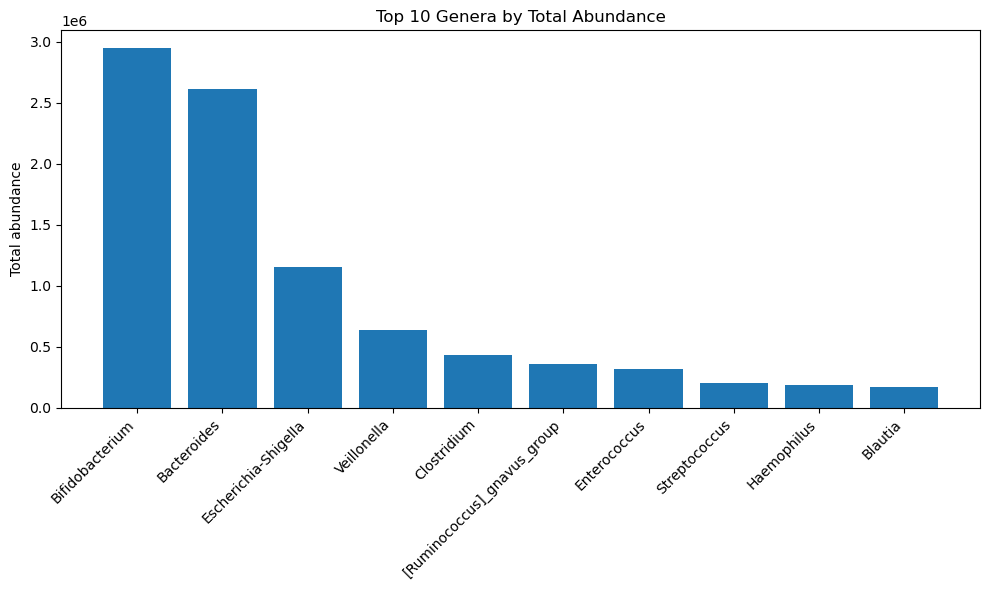

In [40]:
# Path to exported BIOM file
biom_path = f"{out_dir}/exported/feature-table.biom"
print("Loading BIOM from:", biom_path)

# Load BIOM table
table = load_table(biom_path)
df = table.to_dataframe(dense=True)

# Extract genus from taxonomy strings
prefix = prefix_map[selected_level]
df.index = df.index.str.extract(fr"{prefix}([^;]+)")[0]

# Drop rows where genus could not be extracted
df_clean = df.dropna()

# Total abundance per genus
genus_abundance = df_clean.sum(axis=1).sort_values(ascending=False)
top10 = genus_abundance.head(10)

# Plot top 10 genera
plt.figure(figsize=(10, 6))
plt.bar(top10.index, top10.values)
plt.xticks(rotation=45, ha='right')
plt.ylabel("Total abundance")
plt.title("Top 10 Genera by Total Abundance")
plt.tight_layout()
plt.show()

## 2. Test for overfitting or underfitting

To assess whether the classifier overfits or underfits, we first need to isolate the samples that were used for training the model. QIIME saves the training sample IDs in the training_targets.qza file. In this step, we load those IDs and filter our cleaned metadata so that it contains only the samples included in the training split. This ensures that the next steps evaluate performance on exactly the same data the classifier was trained on.

<div style="border:2px solid red; padding:10px; background-color:#ffe6e6;">
<b>TODO:</b> This part of the analysis still needs to be fixed. The results look weird -> all 1's
</div>


In [41]:
# Path to classifier results
train_targets_fp = f"{qiime_clf_dir}/training_targets.qza"

# Load cleaned metadata (sample IDs are the index)
df_metadata = pd.read_csv(clean_meta_path, sep="\t", index_col=0)

print("Full metadata shape:", df_metadata.shape)
print("Metadata index example:", df_metadata.index[:5])

# Load training target sample IDs
ser_train_targets = q2.Artifact.load(train_targets_fp).view(pd.Series)

print("Training target shape:", ser_train_targets.shape)

# Subset metadata using index matching
df_metadata_train = df_metadata.loc[df_metadata.index.intersection(ser_train_targets.index)]

print("Filtered training metadata shape:", df_metadata_train.shape)

# Save training-only metadata
train_meta_fp = f"{out_dir}/metadata_train_only.tsv"
df_metadata_train.to_csv(train_meta_fp, sep="\t")

print("Saved training-only metadata:", train_meta_fp)

Full metadata shape: (270, 9)
Metadata index example: Index(['SRR8118533', 'SRR8118537', 'SRR8118564', 'SRR8118650', 'SRR8118652'], dtype='object', name='id')
Training target shape: (216,)
Filtered training metadata shape: (216, 9)
Saved training-only metadata: ../data/processed/classification/results-diet_milk-genus-ExtraTreesClassifier/metadata_train_only.tsv


/opt/conda/lib/python3.10/site-packages/q2_sample_classifier/_transformer.py:69: FutureWarning: errors='ignore' is deprecated and will raise in a future version. Use to_numeric without passing `errors` and catch exceptions explicitly instead
  return pd.to_numeric(df.iloc[:, 0], errors='ignore')


Now that we have metadata for only the training samples, we filter the feature table as well. This creates a feature table that contains only the samples used during training. This step ensures that when we make predictions, the input exactly matches the data the classifier originally learned from.

In [42]:
train_table_fp = f"{out_dir}/collapsed_table_train_only.qza"

! qiime feature-table filter-samples \
  --i-table "{out_dir}/collapsed_table_filtered.qza" \
  --m-metadata-file "{train_meta_fp}" \
  --o-filtered-table "{train_table_fp}"

print("Created training-only feature table:", train_table_fp)

/opt/conda/lib/python3.10/site-packages/unifrac/__init__.py:9: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources
Saved FeatureTable[Frequency] to: ../data/processed/classification/results-diet_milk-genus-ExtraTreesClassifier/collapsed_table_train_only.qza
Created training-only feature table: ../data/processed/classification/results-diet_milk-genus-ExtraTreesClassifier/collapsed_table_train_only.qza


Next, we use the trained model to predict labels for the training samples. By comparing the model’s predictions to the true training labels, we will later be able to measure how well the model fits the training data. Strong performance here is expected, but if it is too perfect, it may indicate overfitting.

In [43]:
train_pred_dir = f"{qiime_clf_dir}/training-predictions"

# Remove old directory if it exists
! rm -rf "{train_pred_dir}"
! mkdir -p "{train_pred_dir}"

pred_fp = f"{train_pred_dir}/predictions.qza"
prob_fp = f"{train_pred_dir}/probabilities.qza"

# Predict labels for the training samples
! qiime sample-classifier predict-classification \
  --i-table "{train_table_fp}" \
  --i-sample-estimator "{qiime_clf_dir}/sample_estimator.qza" \
  --o-predictions "{pred_fp}" \
  --o-probabilities "{prob_fp}"

print("Training predictions saved to:", train_pred_dir)

/opt/conda/lib/python3.10/site-packages/unifrac/__init__.py:9: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources
Saved SampleData[ClassifierPredictions] to: ../data/processed/classification/qiime-classifier-diet_milk-genus-ExtraTreesClassifier/training-predictions/predictions.qza
Saved SampleData[Probabilities] to: ../data/processed/classification/qiime-classifier-diet_milk-genus-ExtraTreesClassifier/training-predictions/probabilities.qza
Training predictions saved to: ../data/processed/classification/qiime-classifier-diet_milk-genus-ExtraTreesClassifier/training-predictions


Here we compute a confusion matrix for the training predictions. This visualization summarizes how often the model predicted each class correctly or incorrectly on the training data. We will compare this to the test confusion matrix to understand whether the model is overfitting, underfitting, or performing as expected.

In [44]:
train_perf_fp = f"{train_pred_dir}/training_performance.qzv"

! qiime sample-classifier confusion-matrix \
  --i-predictions "{train_pred_dir}/predictions.qza" \
  --i-probabilities "{train_pred_dir}/probabilities.qza" \
  --m-truth-file "{train_meta_fp}" \
  --m-truth-column "{column_to_investigate}" \
  --o-visualization "{train_perf_fp}"

train_perf_fp

/opt/conda/lib/python3.10/site-packages/unifrac/__init__.py:9: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources
Saved Visualization to: ../data/processed/classification/qiime-classifier-diet_milk-genus-ExtraTreesClassifier/training-predictions/training_performance.qzv


'../data/processed/classification/qiime-classifier-diet_milk-genus-ExtraTreesClassifier/training-predictions/training_performance.qzv'

Finally, we display the training performance visualization. By comparing the training accuracy with the earlier test accuracy, we can detect overfitting (large gap) or underfitting (both low). This completes the evaluation of model fit.

In [45]:
Visualization.load(f"{train_pred_dir}/training_performance.qzv")

<visualization: Visualization uuid: 8bbba544-308f-4d9e-a7a8-4ec6dfdd9a83>

Good fit: training and test accuracy are both high and similar → model generalises well.

Overfitting: training accuracy is high but test accuracy is much lower → model learned the training data too closely.

Underfitting: both training and test accuracy are low → model did not learn enough structure.

Unusual case: high test accuracy but low training accuracy → may indicate noise or mismatched metadata.

<div style="border:2px solid red; padding:10px; background-color:#ffe6e6;">
<b>TODO:</b> Possible to still do extra -> notebook W9: Throughout this exercise sheet we have always employed a 80%:20% train:test split. Allowing us to evaluate the trained model on the test samples (20%). In some cases you are interested in creating predictions for all available samples, without using the same samples to train the model (! no data leakage). If you are interested in how this works (could be helpful for your group project), have a look at the section "Nested cross-validation provides predictions for all samples" in [this Q2 tutorial](https://docs.qiime2.org/2024.5/tutorials/sample-classifier/). 
</div>


# References




QIIME 2 Documentation. Sample Classifier Tutorial. Version 2024.5.
https://docs.qiime2.org/2024.5/tutorials/sample-classifier/